In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    Callback, ModelCheckpoint, TensorBoard, EarlyStopping,
    ReduceLROnPlateau, LearningRateScheduler
)


2025-11-05 10:59:09.053755: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762340349.258978      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762340349.315092      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os

root = "/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset"
print(os.listdir(root))


['NonViolence', 'Violence']


In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


In [4]:
dataset_path = "/kaggle/input/real-life-violence-situations-dataset/Real Life Violence Dataset"
classes = ["NonViolence", "Violence"]

frames = []
labels = []

frame_extract_rate = 10  # take 1 frame every 10 frames

for category in classes:
    folder = os.path.join(dataset_path, category)
    label = 0 if category == "NonViolence" else 1
    print(f"📂 Processing videos in: {category}")

    for file in tqdm(os.listdir(folder)[0:500]):
        video_path = os.path.join(folder, file)

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print("⚠️ Error opening video:", video_path)
            continue

        frame_num = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_num % frame_extract_rate == 0:
                frame = cv2.resize(frame, (224, 224))
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
                labels.append(label)

            frame_num += 1

        cap.release()

frames = np.array(frames)
labels = np.array(labels)

print("✅ Extraction Done")
print("Frames shape:", frames.shape)
print("Labels shape:", labels.shape)


📂 Processing videos in: NonViolence


 99%|█████████▉| 496/500 [00:35<00:00, 10.04it/s][h264 @ 0x33dc1840] mb_type 104 in P slice too large at 98 31
[h264 @ 0x33dc1840] error while decoding MB 98 31
100%|██████████| 500/500 [00:36<00:00, 13.72it/s]


📂 Processing videos in: Violence


100%|██████████| 500/500 [01:07<00:00,  7.42it/s]


✅ Extraction Done
Frames shape: (13801, 224, 224, 3)
Labels shape: (13801,)


In [5]:
frames = frames.astype("float32") / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    frames, labels, test_size=0.2, random_state=42, stratify=labels
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(11040, 224, 224, 3) (11040,)
(2761, 224, 224, 3) (2761,)


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=12,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Load MobileNetV2 base
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

# Freeze base layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


I0000 00:00:1762340476.415384      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2)
ckpt = ModelCheckpoint("mobilenetv2_violence.weights.h5", monitor="val_loss",
                       save_best_only=True, save_weights_only=True)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_test, y_test),
    epochs=15,
    callbacks=[es, rlr, ckpt]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1762340486.942264    4098 service.cc:148] XLA service 0x78e6f4002a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762340486.943030    4098 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1762340487.974022    4098 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/345 ━━━━━━━━━━━━━━━━━━━━ 1:10:33 12s/step - accuracy: 0.4062 - loss: 1.0120

I0000 00:00:1762340491.946961    4098 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


345/345 ━━━━━━━━━━━━━━━━━━━━ 121s 315ms/step - accuracy: 0.7705 - loss: 0.4565 - val_accuracy: 0.9250 - val_loss: 0.2016 - learning_rate: 1.0000e-04
Epoch 2/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 99s 286ms/step - accuracy: 0.8995 - loss: 0.2408 - val_accuracy: 0.9254 - val_loss: 0.1807 - learning_rate: 1.0000e-04
Epoch 3/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 98s 284ms/step - accuracy: 0.9306 - loss: 0.1873 - val_accuracy: 0.9388 - val_loss: 0.1555 - learning_rate: 1.0000e-04
Epoch 4/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 98s 285ms/step - accuracy: 0.9342 - loss: 0.1681 - val_accuracy: 0.9424 - val_loss: 0.1359 - learning_rate: 1.0000e-04
Epoch 5/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 99s 287ms/step - accuracy: 0.9454 - loss: 0.1409 - val_accuracy: 0.9410 - val_loss: 0.1445 - learning_rate: 1.0000e-04
Epoch 6/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 98s 285ms/step - accuracy: 0.9521 - loss: 0.1337 - val_accuracy: 0.9460 - val_loss: 0.1325 - learning_rate: 1.0000e-04
Epoch 7/15
345/345 ━━━━━━━━━━━━━━━━━━━━ 98s 284ms/step -

In [8]:
model.load_weights("mobilenetv2_violence.weights.h5")

loss, acc = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {acc:.4f}")


87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9765 - loss: 0.0680
✅ Test Accuracy: 0.9775


In [12]:
def predict_video(video_path, frame_step=10):
    cap = cv2.VideoCapture(video_path)
    preds = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        if int(cap.get(1)) % frame_step == 0:
            img = cv2.resize(frame, (224,224))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype("float32") / 255.0
            img = np.expand_dims(img, axis=0)
            
            pred = model.predict(img)[0][0]
            preds.append(pred)

    cap.release()

    final_score = np.mean(preds)
    label = "Violence" if final_score > 0.5 else "Non-Violence"

    print(f"Prediction: {label} | Score: {final_score:.3f}")
    return label, final_score


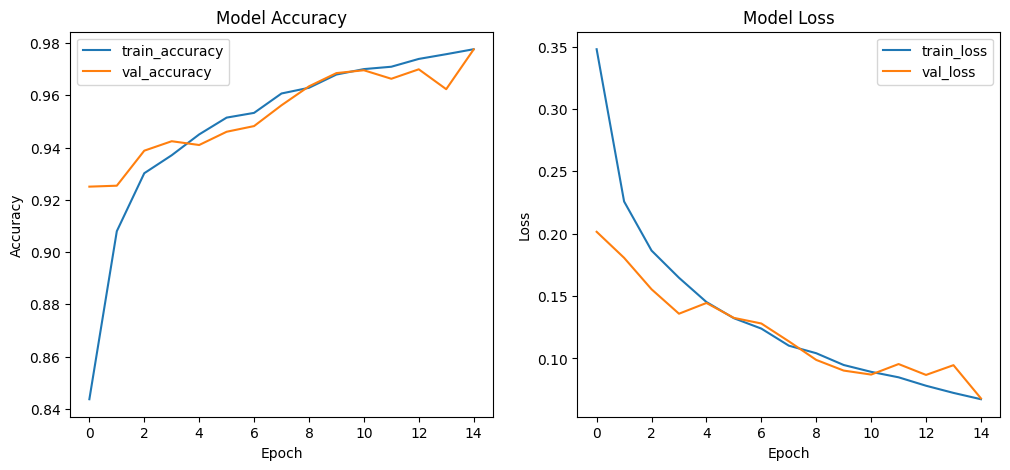

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()


87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step


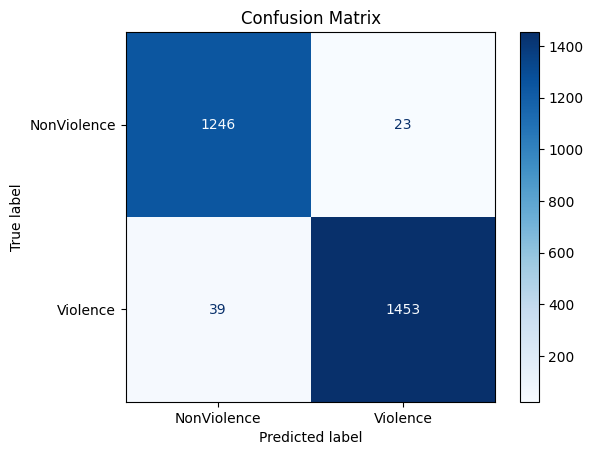

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_pred = (model.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NonViolence","Violence"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["NonViolence", "Violence"]))


              precision    recall  f1-score   support

 NonViolence       0.97      0.98      0.98      1269
    Violence       0.98      0.97      0.98      1492

    accuracy                           0.98      2761
   macro avg       0.98      0.98      0.98      2761
weighted avg       0.98      0.98      0.98      2761



87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


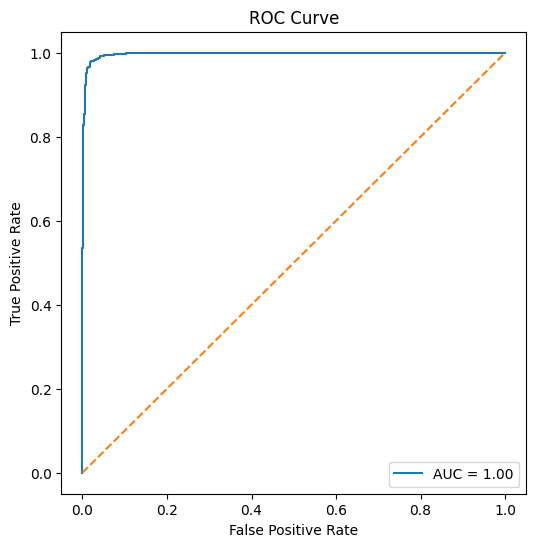

In [17]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")  # baseline
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [18]:
plt.savefig("training_curves.png", dpi=300)
plt.savefig("confusion_matrix.png", dpi=300)


<Figure size 640x480 with 0 Axes>